In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import open3d

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
video_path = "/home/alexis/Documents/COMP558/COMP558-FinalProject/videos/VIDEO-20250109-142924.mp4"
depth_path = "/home/alexis/Documents/COMP558/COMP558-FinalProject/videos/DEPTH-20250109-142924.mp4"

In [3]:
# region of interest
bx, by, bw, bh = 275, 235, 115, 115

expand_x, expand_y = 0, 0

In [4]:
bx = int(bx - expand_x/2)
by = int(by - expand_y/2)

bw = bw + expand_x
bh = bh + expand_y

In [5]:
cap = cv.VideoCapture(depth_path)

vid_ret, img = cap.read()
# img = img[y:y+h, x:x+w, ...]

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray = cv.normalize(gray, None, alpha = 0, beta = 255, norm_type = cv.NORM_MINMAX)

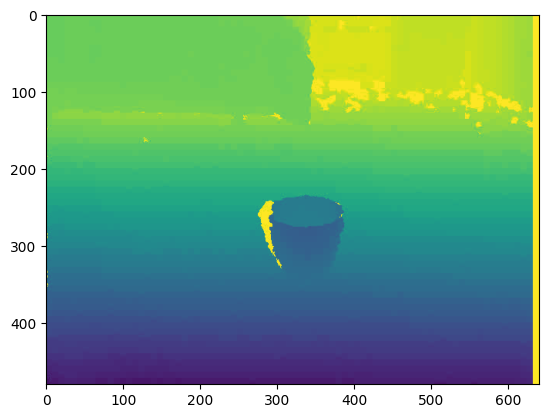

In [6]:
plt.imshow(gray)
plt.show()

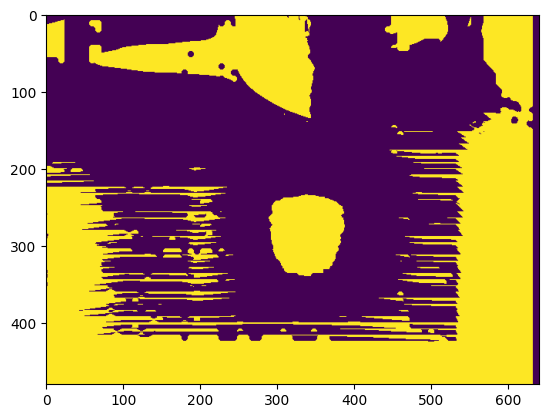

In [7]:
ret, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

blurred = cv.medianBlur(gray, 5)
thresh = cv.adaptiveThreshold(blurred, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY_INV, 201, 2)

plt.imshow(thresh)
plt.show()

In [8]:
kernel = np.ones((3, 3), np.uint8)
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations = 2)

sure_bg = cv.dilate(opening, kernel, iterations = 3)

dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)
ret, sure_fg = cv.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg, sure_fg)

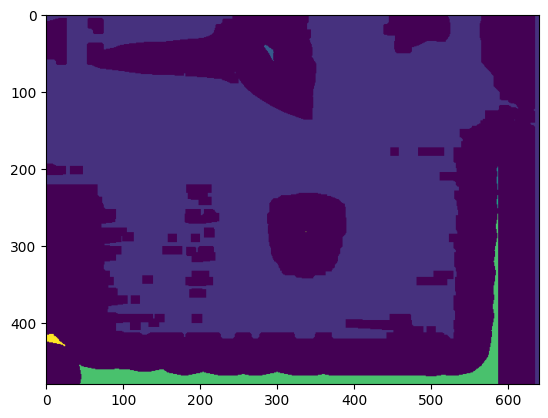

In [9]:
ret, markers = cv.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

plt.imshow(markers)
plt.show()

In [10]:
print(img.shape)

(480, 640, 3)


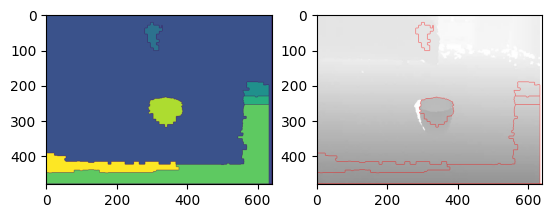

In [11]:
markers = cv.watershed(img, markers)

img2 = img.copy()
img2[markers == -1] = [255, 0, 0]

plt.subplot(1, 2, 1)
plt.imshow(markers)

plt.subplot(1, 2, 2)
plt.imshow(img2)

plt.show()

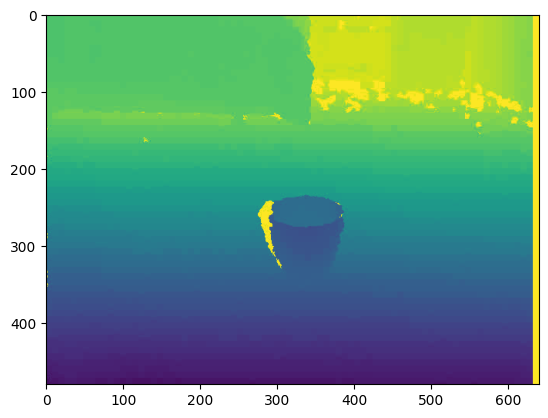

In [12]:
distance = 0.1236 * np.tan(gray / 2842.5 + 1.1863)

plt.imshow(distance)
plt.show()

In [13]:
cap = cv.VideoCapture(video_path)

vid_ret, rgb = cap.read()
rgb = rgb[..., ::-1]

In [14]:
minDistance = -10
scaleFactor = 0.0021 / (2**2)

img_h, img_w = img.shape[0:2]

a = np.arange(img_w) - img_w // 2
b = np.arange(img_h) - img_h // 2

i, j = np.meshgrid(a, b)


z = distance * (2**2)
x = (i - img_w / 2) * (z + minDistance) * scaleFactor
y = (j - img_h / 2) * (z + minDistance) * scaleFactor

In [15]:
coordinates = np.stack((x, y, z), axis = 2) 

colors = rgb[j.flatten() + img_h //2, i.flatten() + img_w // 2, :]

In [16]:
pcd = open3d.geometry.PointCloud()

pcd.points = open3d.utility.Vector3dVector(coordinates.reshape(-1, 3))
pcd.colors = open3d.utility.Vector3dVector(colors/255)

In [17]:
open3d.visualization.draw_geometries([pcd])

In [18]:
z_subset = z[by:by + bh, bx:bx + bw]
z_avg = z_subset[markers[by:by + bh, bx:bx + bw] == 1]

print(np.mean(z_avg))


1.3881443694804712
